# 🗣️ User Feedback Analyzer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/mini-saas-products/feedback-analyzer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=mini-saas-products/feedback-analyzer/demo.ipynb)

> **"We have 10K reviews and no insights."** A pile of reviews is not insight. This turns raw feedback into a sentiment split, ranked complaints, ranked praises, and the one thing to fix first.

**This notebook covers:**
1. Lexicon sentiment scoring — with **negation handling** ("not good" ≠ good)
2. Theme mining (what people actually talk about)
3. Splitting themes into complaints vs. praises
4. A sentiment chart
5. Try your own reviews


## Step 1 — Sentiment with negation

Full ML sentiment models are overkill for a first pass. A lexicon (positive/negative word lists) plus one rule — **flip polarity when a negator precedes the word** — gets you surprisingly far and runs instantly with zero dependencies. The negation rule is what separates a toy from something usable: "not good" must score negative.


In [1]:
from __future__ import annotations

import re
from collections import Counter
from typing import List, Tuple

_TOK = re.compile(r"[a-z']+")
POSITIVE = {"love","loved","great","excellent","amazing","awesome","perfect","good","fast","easy",
            "intuitive","reliable","helpful","fantastic","smooth","best","recommend","happy",
            "beautiful","responsive","affordable","solid","worth"}
NEGATIVE = {"hate","bad","terrible","awful","horrible","slow","buggy","crash","crashes","broken",
            "confusing","expensive","useless","disappointed","poor","frustrating","difficult",
            "worst","laggy","unreliable","overpriced","clunky","glitchy","annoying"}
NEGATORS = {"not","no","never","n't","without","hardly"}


def sentiment(text: str) -> Tuple[str, float]:
    toks = _TOK.findall(text.lower())
    pos = neg = 0
    for i, tok in enumerate(toks):
        negated = any(w in NEGATORS for w in toks[max(0, i-2):i])
        if tok in POSITIVE:
            neg, pos = (neg+1, pos) if negated else (neg, pos+1)
        elif tok in NEGATIVE:
            pos, neg = (pos+1, neg) if negated else (pos, neg+1)
    total = pos + neg
    score = 0.0 if total == 0 else (pos - neg) / total
    label = "neutral" if abs(score) < 0.2 else ("positive" if score > 0 else "negative")
    return label, round(score, 2)


for t in ["Love this, so fast and easy!", "not good, very confusing", "It crashes on startup"]:
    print(f"{sentiment(t)}  <- {t}")


('positive', 1.0)  <- Love this, so fast and easy!
('negative', -1.0)  <- not good, very confusing
('negative', -1.0)  <- It crashes on startup


## Step 2 — Sample reviews & sentiment split

A realistic mixed batch. Scoring every review gives the distribution — the first number a PM asks for.


In [2]:
reviews = [
    "Love this app, the interface is so intuitive and fast.",
    "The battery drain is terrible, my phone dies in hours.",
    "Great customer service, they resolved my issue quickly.",
    "Way too expensive for what it offers. Not worth the price.",
    "The app keeps crashing every time I upload a photo.",
    "Beautiful design and super easy to use. Highly recommend!",
    "Sync is unreliable, my data disappeared twice this week.",
    "Customer support was helpful and responsive, solid experience.",
    "Confusing navigation, I can never find the settings.",
    "Fast, reliable, and affordable. Best in its category.",
    "The latest update is buggy and slow, please fix it.",
    "Not good. The onboarding is frustrating and unclear.",
    "Amazing value, the premium features are worth every penny.",
    "It crashes on startup, completely useless right now.",
    "Smooth performance and the search is really responsive.",
    "Overpriced subscription with too many bugs.",
    "Easy setup, worked perfectly out of the box.",
    "Terrible battery life and the notifications are annoying.",
    "The customer service team is fantastic and quick to help.",
    "Laggy and clunky since the redesign, disappointed.",
]
labels = [sentiment(r)[0] for r in reviews]
dist = Counter(labels)
print("Sentiment split:", dict(dist))
nps = round(100 * (dist["positive"] - dist["negative"]) / len(reviews), 1)
print(f"NPS-like (%pos - %neg): {nps:+}")


Sentiment split: {'positive': 9, 'negative': 10, 'neutral': 1}
NPS-like (%pos - %neg): -5.0


## Step 3 — Theme mining: complaints vs. praises

The split tells you *how many* are unhappy; themes tell you *why*. Count content words + bigrams **separately** within negative and positive reviews. Negative themes = your bug backlog; positive themes = your marketing copy.


In [3]:
STOP = {"the","a","an","is","are","was","were","it","this","that","i","we","you","to","of","for",
        "in","on","and","or","but","my","so","very","with","at","as","be","have","has","they",
        "app","would","really","just","get","got","me","too","if","your","our","all","can","do",
        "since","every","time","right","now"}


def themes(texts: List[str], k: int = 6) -> List[Tuple[str, int]]:
    uni, bi = Counter(), Counter()
    for t in texts:
        toks = [w for w in _TOK.findall(t.lower()) if w not in STOP and w not in NEGATORS]
        uni.update([w for w in toks if w not in POSITIVE and w not in NEGATIVE and len(w) > 2])
        for a, b in zip(toks, toks[1:]):
            if len(a) > 2 and len(b) > 2:
                bi.update([f"{a} {b}"])
    merged = uni + Counter({w: c + 1 for w, c in bi.items() if c >= 2})
    return merged.most_common(k)


neg_texts = [r for r, l in zip(reviews, labels) if l == "negative"]
pos_texts = [r for r, l in zip(reviews, labels) if l == "positive"]
print("🔴 Complaints:", themes(neg_texts))
print("🟢 Praises:   ", themes(pos_texts))


🔴 Complaints: [('battery', 2), ('drain', 1), ('phone', 1), ('dies', 1), ('hours', 1), ('way', 1)]
🟢 Praises:    [('customer', 3), ('customer service', 3), ('service', 2), ('interface', 1), ('resolved', 1), ('issue', 1)]


## Step 4 — Visualize the split

The one chart that goes in the PM update.


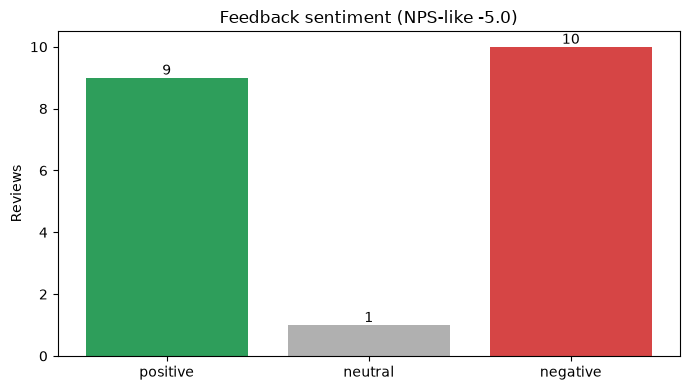

In [4]:
import matplotlib.pyplot as plt

order = ["positive", "neutral", "negative"]
counts = [dist.get(o, 0) for o in order]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(order, counts, color=["#2e9e5b", "#b0b0b0", "#d64545"])
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, c + 0.1, str(c), ha="center")
ax.set_ylabel("Reviews")
ax.set_title(f"Feedback sentiment (NPS-like {nps:+})")
plt.tight_layout()
plt.savefig("feedback_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

- **Split first:** one lexicon pass + a negation rule gives the sentiment distribution instantly.
- **Themes localize:** mining negative vs. positive reviews separately turns "people are unhappy" into "battery and crashes" — an actual backlog.
- **One takeaway:** rank complaints by frequency and fix the top one. That's the whole job.

The full app adds paste-your-own reviews, per-review scores, and an optional Claude summary that writes the PM-ready takeaway.


## Try your own reviews

Paste your reviews (App Store, G2, support tickets, NPS comments) into the list and re-run. For real scale, swap the lexicon for a transformer sentiment model — the theme-mining + complaint-ranking structure stays identical.


In [5]:
# my_reviews = ["...", "..."]
# my_labels = [sentiment(r)[0] for r in my_reviews]
# print(Counter(my_labels))
# print("Complaints:", themes([r for r, l in zip(my_reviews, my_labels) if l == "negative"]))


---
Part of **[Phoebe's FDE Portfolio](https://github.com/phoebefu6/phoebe-the-builder)** — Day 52, Mini SaaS Products.

For the interactive Streamlit version (paste reviews, per-review scores, complaint/praise tables, Claude summary):
```bash
pip install -r requirements.txt
streamlit run app.py
```
